In [2]:
library(limma)
library(Biobase)
library(dplyr)
library(ggplot2)
library(magrittr)
library(ggrepel)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.



Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following

Expression Set object

In [3]:
data <- read.csv("extdata/mrna20k_emci.csv", header=TRUE)

In [4]:
data_1 = data[,c(-1,-2)]

In [5]:
rownames(data_1) = data$index

In [6]:
data_2 = t(data_1)

In [7]:
head(data_2)

,002_S_2043,002_S_2073,002_S_4237,002_S_4447,002_S_4473,003_S_2374,005_S_2390,005_S_4168,005_S_4185,007_S_2058,⋯,141_S_2210,141_S_4160,141_S_4232,141_S_4438,153_S_2109,153_S_4297,153_S_4621,941_S_2060,941_S_4036,941_S_4420
A2ML1,2.150,2.241,2.257,2.391,2.152,2.283,1.985,2.050,2.063,2.223,⋯,2.063,2.029,2.166,2.209,2.379,2.113,2.573,2.065,2.019,2.195
A4GALT,2.600,2.553,2.249,2.311,2.293,2.338,2.257,2.336,2.324,2.668,⋯,2.296,1.972,2.263,2.678,2.168,2.373,2.085,2.295,2.769,2.336
A4GNT,2.120,1.995,1.946,1.922,2.022,1.821,2.082,1.991,1.882,2.004,⋯,2.187,2.026,1.853,1.841,1.991,1.887,1.894,2.163,1.950,1.962
AAAS,6.704,6.675,6.511,7.120,6.447,6.618,6.627,7.399,6.600,7.508,⋯,7.219,6.547,7.372,7.290,7.306,6.877,6.963,7.156,7.195,6.621
AACS,2.474,2.343,2.511,2.484,2.304,2.184,2.584,2.358,2.368,2.670,⋯,2.169,2.464,2.534,2.477,2.005,2.205,2.853,2.514,2.519,2.530
AACSP1,2.389,2.407,2.512,2.574,2.491,2.683,2.427,2.442,2.653,2.522,⋯,2.382,2.283,2.110,2.675,2.488,2.535,2.871,2.539,2.402,2.205


In [8]:
subtype_info<-read.csv("extdata/cn_emci_lmci_ad_clin_pseudotime.csv",header=TRUE)
table(subtype_info$SNF)
name_emci1<-subtype_info$PID[which(subtype_info$SNF=="emcisubtype1")]
name_emci2<-subtype_info$PID[which(subtype_info$SNF=="emcisubtype2")]


          AD           CN emcisubtype1 emcisubtype2 lmcisubtype1 lmcisubtype2 
         339          534          108           93           85          115 

In [9]:
# subset clusters for c=2 SNF MRNA + METAB
data_subset_1=as.matrix(data_2[,name_emci1])
data_subset_2=as.matrix(data_2[,name_emci2])
dim(data_subset_1)
dim(data_subset_2)

data_subset = cbind(data_subset_1,data_subset_2)

dataset <- ExpressionSet(assayData=as.matrix(data_subset))

sub1 = dim(data_subset_1)[2]
sub2 = dim(data_subset_2)[2]
design = cbind(c(c(rep(1, sub1)),c(rep(0, sub2))),c(c(rep(0, sub1)),c(rep(1, sub2))))
colnames(design) <- c("subset1","subset2")

[1] 20032   108

[1] 20032    93

In [10]:
fit <- lmFit(data_subset, design)
cont.matrix <- makeContrasts(contrasts = "subset2-subset1", levels=design) # subset1 as control 
fit2 <- contrasts.fit(fit, cont.matrix)
fit2 <- eBayes(fit2, trend=FALSE)
limma_result_fit <- topTable(fit2,  coef=1, n=Inf)
limma_result_fit$gene_symbol <- row.names(limma_result_fit)

In [11]:
limma_result_fit

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene_symbol
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
LUC7L3,0.6153943,7.207846,6.963423,4.568928e-11,9.152476e-07,14.694880,LUC7L3
KDM6A,0.4644483,4.687607,6.755762,1.484915e-10,1.035676e-06,13.586568,KDM6A
ZMAT1,0.7844973,3.832726,6.748015,1.551032e-10,1.035676e-06,13.545619,ZMAT1
DDX5,0.2709642,10.356816,6.248745,2.409721e-09,9.482085e-06,10.969573,DDX5
UROS,-0.2309937,6.124095,-6.247802,2.421935e-09,9.482085e-06,10.964831,UROS
HK3,-0.3504250,6.722761,-6.218058,2.840081e-09,9.482085e-06,10.815446,HK3
F8A2,-0.2045573,4.760632,-6.129718,4.544948e-09,1.285633e-05,10.374567,F8A2
CD53,0.2323336,9.869100,6.106676,5.134316e-09,1.285633e-05,10.260270,CD53
XIST,1.4182019,3.468701,6.074115,6.096700e-09,1.356990e-05,10.099249,XIST


Warning message:
“Removed 19797 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 225 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Saving 6.67 x 6.67 in image
Warning message:
“Removed 19797 rows containing missing values (`geom_text_repel()`).”
Warning message:
“ggrepel: 225 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


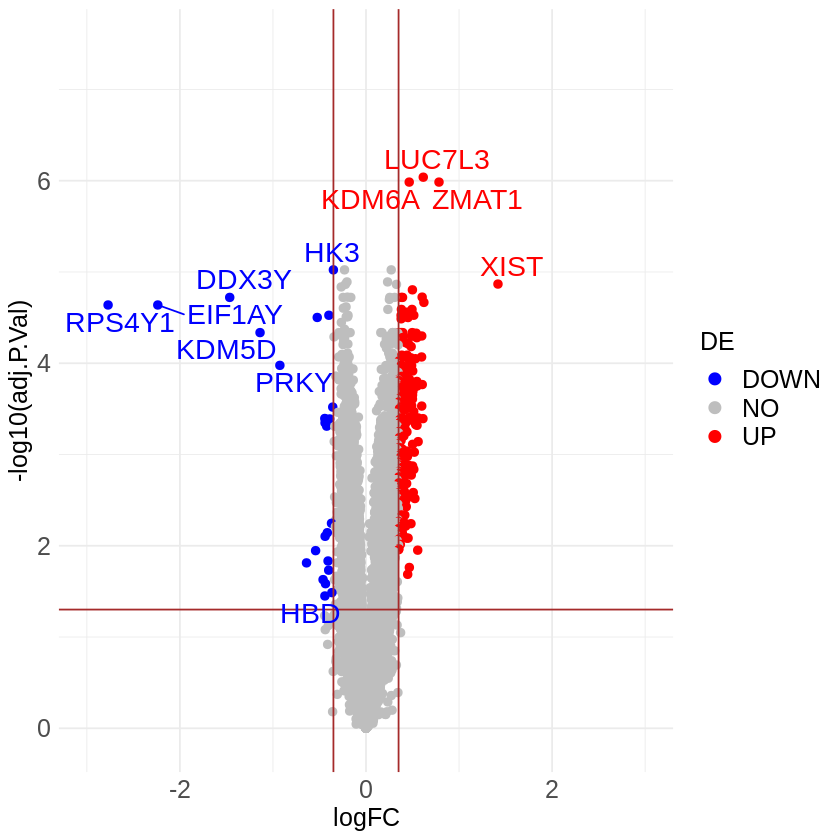

In [12]:
#### plot volcano

fold_cutoff = 0.35

limma_result_fit$diffexpressed <- "NO"
# if log2Foldchange > 0.5 and pvalue < 0.05, set as "UP" 
limma_result_fit$diffexpressed[limma_result_fit$logFC > fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "UP"
# if log2Foldchange < -0.5 and pvalue < 0.05, set as "DOWN"
limma_result_fit$diffexpressed[limma_result_fit$logFC < -fold_cutoff & limma_result_fit$adj.P.Val < 0.05] <- "DOWN"

limma_result_fit$delabel <- NA

limma_result_fit$delabel[limma_result_fit$diffexpressed != "NO"] <- limma_result_fit$gene_symbol[limma_result_fit$diffexpressed != "NO"]

ggplot(data=limma_result_fit, aes(x=logFC, y=-log10(adj.P.Val),col=diffexpressed)) +
        geom_point(size=2) +
        theme_minimal() +
        scale_color_manual(breaks=c("DOWN","NO","UP"),values=c("blue", "grey", "red")) +
        guides(color=guide_legend(title = "DE",override.aes = list(size = 3))) +
        geom_vline(xintercept=c(-fold_cutoff, fold_cutoff), col="brown") +
        geom_hline(yintercept=-log10(0.05), col="brown") + 
        xlim(-3, 3) +ylim(-0.1,7.5) +
        theme(axis.title = element_text(size = 15),axis.text=element_text(size=15),legend.title=element_text(size=15),legend.text=element_text(size=15))+
        geom_text_repel(aes(label=delabel),size=6,max.overlaps=10)
        
ggsave("figs/RP_2c.png",dpi=600)    


In [13]:
### get the DE Genes

limma_DE = limma_result_fit[which(limma_result_fit$diffexpressed != "NO"), ] 

In [14]:
limma_DE

,logFC,AveExpr,t,P.Value,adj.P.Val,B,gene_symbol,diffexpressed,delabel
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
LUC7L3,0.6153943,7.207846,6.963423,4.568928e-11,9.152476e-07,14.694880,LUC7L3,UP,LUC7L3
KDM6A,0.4644483,4.687607,6.755762,1.484915e-10,1.035676e-06,13.586568,KDM6A,UP,KDM6A
ZMAT1,0.7844973,3.832726,6.748015,1.551032e-10,1.035676e-06,13.545619,ZMAT1,UP,ZMAT1
HK3,-0.3504250,6.722761,-6.218058,2.840081e-09,9.482085e-06,10.815446,HK3,DOWN,HK3
XIST,1.4182019,3.468701,6.074115,6.096700e-09,1.356990e-05,10.099249,XIST,UP,XIST
PNISR,0.4987351,7.823582,5.976168,1.018552e-08,1.569511e-05,9.618412,PNISR,UP,PNISR
CHORDC1,0.6033683,4.550254,5.914684,1.401819e-08,1.886180e-05,9.319319,CHORDC1,UP,CHORDC1
FBXW7,0.3781024,7.916711,5.869172,1.773213e-08,1.899947e-05,9.099305,FBXW7,UP,FBXW7
ZNF140,0.3924875,4.235154,5.856843,1.889391e-08,1.899947e-05,9.039907,ZNF140,UP,ZNF140


In [15]:
limma_DE$delabel

[1] "LUC7L3"     "KDM6A"      "ZMAT1"      "HK3"        "XIST"      
  [6] "PNISR"      "CHORDC1"    "FBXW7"      "ZNF140"     "DDX3Y"     
 [11] "CD46"       "EIF1AY"     "RPS4Y1"     "OTUD1"      "ODF2L"     
 [16] "CMAHP"      "CBWD3"      "CPT1B"      "RPS6KA3"    "REV3L"     
 [21] "TTTY10"     "PRPF38B"    "ZNF146"     "ADNP"       "KDM5D"     
 [26] "ATP10D"     "NKTR"       "JMJD1C"     "CLK4"       "FAM126B"   
 [31] "CSGALNACT2" "PTPN12"     "TSPAN13"    "ZNF331"     "ITGB1"     
 [36] "PRIMPOL"    "CLINT1"     "N4BP2L2"    "UBR3"       "CAPN7"     
 [41] "ADD3"       "SGMS1"      "CEP170"     "UBR5"       "KRCC1"     
 [46] "PAG1"       "ZNF84"      "TM9SF3"     "MTRF1L"     "FGFR1OP2"  
 [51] "PRKY"       "ZNF439"     "PAPOLG"     "PRPF4B"     "ECHDC1"    
 [56] "COL4A3BP"   "HIAT1"      "MYO5A"      "CEP290"     "FHL1"      
 [61] "PRKRIR"     "FBXL3"      "RNF145"     "SLC33A1"    "EIF1AX"    
 [66] "EDEM3"      "POLI"       "PON2"       "KIAA1468"   "ARMCX3"    
 [71] "SLC35F5"    "VEZT"       "GLCCI1"     "MOSPD2"     "BRWD1"     
 [76] "ZNF382"     "RFXAP"      "RBM7"       "SEC23A"     "ZNF117"    
 [81] "CASP8AP2"   "FCER1A"     "USP32P1.1"  "FAM208A"    "ZNF236"    
 [86] "CCAR1"      "C1ORF27"    "RAB28"      "P2RY10"     "HMGB1"     
 [91] "TVP23C"     "SLMO2"      "FAS"        "SMC4"       "FAM208B"   
 [96] "MYBL1"      "SACS"       "FAR1"       "PCNXL4"     "IRF7"      
[101] "INSIG2"     "RANBP2"     "ORMDL1"     "USP32P1"    "HERC4"     
[106] "TMF1"       "PGRMC2"     "TUBE1"      "MINPP1"     "ATP11C"    
[111] "PROSER1"    "CAMP"       "ZBTB1"      "PWAR6"      "RETN"      
[116] "NUP54"      "SRSF1"      "CDC37L1"    "LRIF1"      "ZNRF2"     
[121] "CRY1"       "KLF10"      "PGLYRP1"    "CMPK1"      "MIB1"      
[126] "NFXL1"      "AVIL"       "PRKX"       "SLC30A5"    "RAB3GAP2"  
[131] "IRS2"       "ATF1"       "S1PR1"      "PNPLA8"     "PLAGL1"    
[136] "PPIL3"      "DNAJB14"    "PTP4A1"     "KLHL28"     "MIS18BP1"  
[141] "TRIM51EP"   "WAPAL"      "LYPLAL1"    "CGGBP1"     "SUB1"      
[146] "TMEM55A"    "MAN1A1"     "ANKRA2"     "FAM135A"    "AKAP12"    
[151] "ZNF267"     "ZBTB21"     "MAP3K7CL"   "TC2N"       "TRNT1"     
[156] "FBXO5"      "TADA1"      "ZNF92"      "PDE3B"      "PCMTD1"    
[161] "TRAM1"      "ATAD2B"     "SOAT1"      "USP53"      "PPIP5K2"   
[166] "CDKN2AIP"   "TGDS"       "SPAG1"      "DNAJC10"    "PKN2"      
[171] "DLEU2L"     "VCPIP1"     "ATAD1"      "PDCL"       "ATXN7"     
[176] "ADO"        "MSANTD4"    "TMEM245"    "ZNF181.1"   "CAAP1"     
[181] "SOX4"       "TSEN15"     "SP3"        "FAM210A"    "LYZ"       
[186] "ETAA1"      "ZNF181"     "C10ORF88"   "TRPC1"      "FIGNL1"    
[191] "NUS1"       "CXCL5.1"    "CNTNAP3B.1" "CAPZA2"     "ASF1A"     
[196] "RORA"       "PPAT"       "LRRC40"     "MEF2A"      "CFH.1"     
[201] "TMEM33"     "TSPAN2"     "AKAP11"     "LY6E"       "TRAPPC13"  
[206] "C2ORF69"    "TMEM170B"   "RFK"        "ADK"        "WDR36"     
[211] "ANKIB1"     "SLPI"       "ABCB10"     "CCDC82"     "C4ORF32"   
[216] "LTF"        "CENPK"      "CLVS1"      "CFH"        "RP2"       
[221] "MPZL1"      "CMTR2"      "GBP3"       "KLHL15"     "CPA3"      
[226] "TXLNG2P"    "HBQ1"       "IFI27"      "TFEC"       "CES1"      
[231] "HDC"        "BPI"        "LCN2"       "GTSCR1"     "HBD"

In [16]:
#write.csv(limma_DE,"DE_results/RP_limmaDE_EMCI.csv")

In [17]:
top10 <- topTable(fit2,  coef=1, n=10,sort.by="p")
top10

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LUC7L3,0.6153943,7.207846,6.963423,4.568928e-11,9.152476e-07,14.694880
KDM6A,0.4644483,4.687607,6.755762,1.484915e-10,1.035676e-06,13.586568
ZMAT1,0.7844973,3.832726,6.748015,1.551032e-10,1.035676e-06,13.545619
DDX5,0.2709642,10.356816,6.248745,2.409721e-09,9.482085e-06,10.969573
UROS,-0.2309937,6.124095,-6.247802,2.421935e-09,9.482085e-06,10.964831
HK3,-0.3504250,6.722761,-6.218058,2.840081e-09,9.482085e-06,10.815446
F8A2,-0.2045573,4.760632,-6.129718,4.544948e-09,1.285633e-05,10.374567
CD53,0.2323336,9.869100,6.106676,5.134316e-09,1.285633e-05,10.260270
XIST,1.4182019,3.468701,6.074115,6.096700e-09,1.356990e-05,10.099249
